# IMPORT LIBRARIES

In [27]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import os

In [28]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)
val_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

In [29]:
train_data = train_datagen.flow_from_directory(
    'train',
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'binary',
    shuffle=True
)

Found 8000 images belonging to 2 classes.


In [30]:
val_data = val_datagen.flow_from_directory(
    'val',
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'binary',
    shuffle=False
)

Found 800 images belonging to 2 classes.


In [31]:
test_data = test_datagen.flow_from_directory(
    'test',
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'binary',
    shuffle = False
)

Found 800 images belonging to 2 classes.


In [32]:
print("Class Labels:", train_data.class_indices)

Class Labels: {'NORMAL': 0, 'PNEUMONIA': 1}


# CNN

In [33]:
model = Sequential([
    Conv2D(32, (3,3),
           activation = 'relu',
           input_shape = (224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3),
           activation = 'relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3),
           activation = 'relu'),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3),
           activation = 'relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(1, activation = 'sigmoid'),
])

In [34]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [35]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,263,809 (73.49 MB)

 Trainable params: 19,263,809 (73.49 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
os.makedirs("models", exist_ok=True)

In [37]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [38]:
checkpoint = ModelCheckpoint(
    "pneumonia_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [39]:
history = model.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1509s 6s/step - accuracy: 0.7803 - loss: 0.4645 - val_accuracy: 0.5038 - val_loss: 0.6808
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1827s 7s/step - accuracy: 0.8554 - loss: 0.2957 - val_accuracy: 0.6925 - val_loss: 0.5311
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 32470s 130s/step - accuracy: 0.8710 - loss: 0.2729 - val_accuracy: 0.8037 - val_loss: 0.4372
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 513s 2s/step - accuracy: 0.8851 - loss: 0.2498 - val_accuracy: 0.8175 - val_loss: 0.4018
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 467s 2s/step - accuracy: 0.8988 - loss: 0.2268 - val_accuracy: 0.8712 - val_loss: 0.3120
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 389s 2s/step - accuracy: 0.9053 - loss: 0.2223 - val_accuracy: 0.8662 - val_loss: 0.3282
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 939s 4s/step - accuracy: 0.9109 - loss: 0.2056 - val_accuracy: 0.9013 - val_loss: 0.2705
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1072s 4s/step - accuracy: 0.9161 - loss: 0.1958 - v

In [40]:
loss, accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {accuracy*100:.2f}%")

25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 670ms/step - accuracy: 0.9325 - loss: 0.1772
Test Accuracy: 93.25%


In [41]:
model.save("pneumonia_model.keras")
print("Model saved successfully")

Model saved successfully


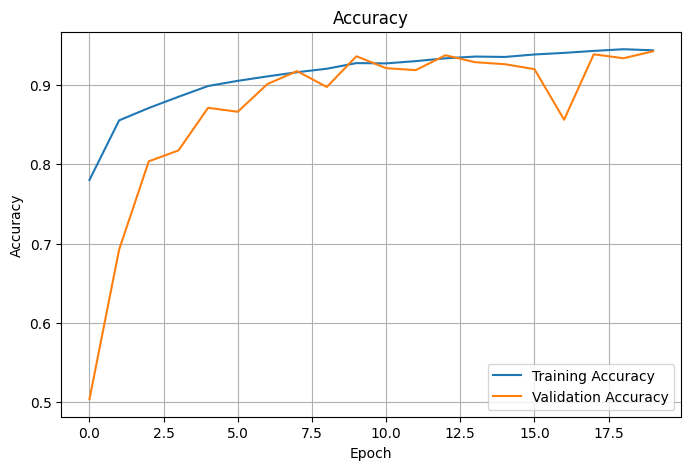

In [42]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

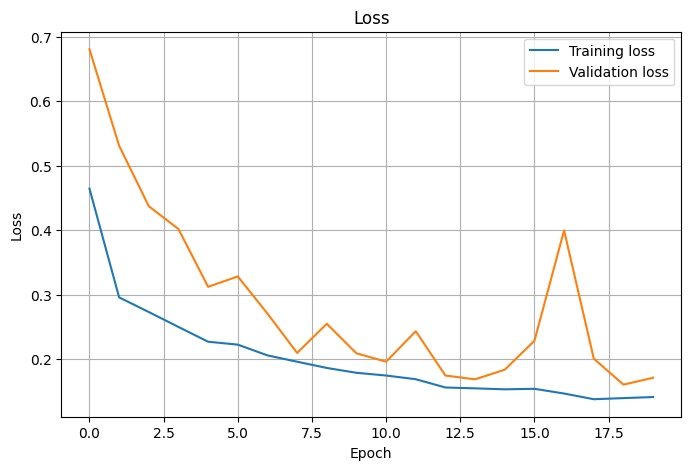

In [43]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [48]:
from tensorflow.keras.preprocessing import image
img = image.load_img(r"train\NORMAL\augmented_555.jpg", target_size=(224,224))
img_arr = image.img_to_array(img)

img_arr = np.expand_dims(img_arr, axis=0)
img_arr = img_arr/255.0
predict = model.predict(img_arr)
print(predict)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[0.0153528]]


In [49]:
classes = ['NORMAL', 'PNEUMONIA']
pred = np.argmax(predict, axis=1)[0]
print('Prediction :',classes[pred])

Prediction : NORMAL
